## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import csv, os, glob, warnings
from sklearn.linear_model  import LinearRegression, LogisticRegression
from sklearn.tree          import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--',
    'font.family': 'sans-serif', 'axes.spines.top': False, 'axes.spines.right': False,
})

COLORS = {
    'house': '#2C3E87', 'bank_rate': '#C0392B',
    'gdp': '#1A7A3C', 'unemp': '#D68910', 'inflation': '#6C3483',
    'train': '#2C3E87', 'test': '#C0392B', 'pred': '#E67E22', 'ok': '#1A7A3C',
}

DATA_DIR = r'.' 

print('✓ Libraries loaded')

✓ Libraries loaded


---
# Stage 1: Data Cleaning

| Dataset | Source | Key issues |
|---|---|---|
| House Prices | Land Registry Price Paid | No headers, commercial types, price outliers |
| Bank Rate | Bank of England | Irregular change dates → need daily forward-fill |
| GDP | ONS | Annual, minimal issues |
| Unemployment | ONS | 8 metadata header rows to skip |
| CPI Inflation | ONS | 4,054-column file — extract headline column only |

### 1.1 House Price — Column Names & Preview

In [2]:
# Column names for Land Registry Price Paid files
COL_NAMES = [
    'uid', 'price', 'date', 'postcode', 'property_type',
    'new_build', 'tenure', 'paon', 'saon', 'street',
    'locality', 'town', 'district', 'county', 'ppd_type', 'record_status'
]

PROPERTY_TYPE_MAP = {
    'D': 'Detached',
    'S': 'Semi-detached',
    'T': 'Terraced',
    'F': 'Flat/Maisonette',
    'O': 'Other (commercial)'
}

# Preview one file
sample = pd.read_csv(
    os.path.join(DATA_DIR, 'pp-2022.csv'),
    header=None, names=COL_NAMES, low_memory=False, nrows=5
)
sample[['uid','price','date','postcode','property_type','new_build','tenure']]

,uid,price,date,postcode,property_type,new_build,tenure
0,{E53EDD2E-2473-83EC-E053-6B04A8C03A59},280000,2022-06-06 00:00,B78 3XA,D,N,F
1,{E53EDD2E-2474-83EC-E053-6B04A8C03A59},312500,2022-06-20 00:00,ST7 4JZ,D,N,F
2,{E53EDD2E-2475-83EC-E053-6B04A8C03A59},150000,2022-06-30 00:00,ST14 7QG,S,N,F
3,{E53EDD2E-2476-83EC-E053-6B04A8C03A59},515000,2022-05-25 00:00,B78 3UG,D,N,F
4,{E53EDD2E-2477-83EC-E053-6B04A8C03A59},262500,2022-07-15 00:00,ST20 0HY,D,N,F


### 1.2 Audit — Issues Per Year (Before Cleaning)

In [3]:
#Audit: count issues per year BEFORE cleaning
audit_rows = []

for yr in range(2018, 2026):
    fpath = os.path.join(DATA_DIR, f'pp-{yr}.csv')
    df = pd.read_csv(fpath, header=None, names=COL_NAMES, low_memory=False)
    df['price'] = pd.to_numeric(df['price'], errors='coerce')

    audit_rows.append({
        'year':        yr,
        'total_rows':  len(df),
        'null_price':  df['price'].isna().sum(),
        'type_O':      (df['property_type'] == 'O').sum(),
        'price_low':   (df['price'] < 10_000).sum(),
        'price_high':  (df['price'] > 10_000_000).sum(),
        'dup_uids':    df.duplicated(subset=['uid']).sum(),
    })

audit_df = pd.DataFrame(audit_rows)
audit_df['total_removed'] = (
    audit_df['null_price'] + audit_df['type_O'] +
    audit_df['price_low']  + audit_df['price_high'] + audit_df['dup_uids']
)
audit_df['pct_removed'] = (audit_df['total_removed'] / audit_df['total_rows'] * 100).round(2)
audit_df

,year,total_rows,null_price,type_O,price_low,price_high,dup_uids,total_removed,pct_removed
0,2018,1037500,0,71416,5384,1430,0,78230,7.54
1,2019,1011935,0,67154,5407,1344,0,73905,7.30
2,2020,896913,0,56057,4552,1187,0,61796,6.89
3,2021,1280702,0,69982,4885,0,0,74867,5.85
4,2022,1075303,0,60488,3727,1434,0,65649,6.11
5,2023,858595,0,51447,3178,1193,0,55818,6.50
6,2024,921562,0,52228,2935,1063,0,56226,6.10
7,2025,757816,0,25403,1035,401,0,26839,3.54


### 1.3 Apply Cleaning Rules

- **Remove property type_O (Other / commercial)**

The Land Registry use type o for transcations that are not standard residential homes, such as commerical or industrial properties. These are removed so that the dataset reflects the housing market only.

- **Drop prices below £10,000 and above £10,000,000**

Residential properties in UK do not normally sell for less than £10,000. Values this low are morelikely to be recording errors, like missing digits. Properties sold for more than £10 million are very rare and are not representative of the wider UK housing market. These are treated as outlier because they can make year-to-year comparisons less reliable.

- **Deduplicate by transaction UID**

Some land registry records are amendments to earlier entries and share the same transaction ID. if these duplicates are kept, the same sale could be counted more than once.to avoid this, only the first occurrence of each UID was retained. 

- **Aggregate to annual median price**

After cleaning, all transactions within each year are summarised using median price. the median was chosen instead of the mean because house prices are usually right-skewed, which means a small number of very expensive properties can pull the mean upward. the median therefore gives a better picture of the typical property price.


In [4]:
#Apply cleaning & build annual summary
PRICE_LOW  = 10_000
PRICE_HIGH = 10_000_000

all_frames   = []
yearly_stats = []

for yr in range(2018, 2026):
    fpath = os.path.join(DATA_DIR, f'pp-{yr}.csv')
    df = pd.read_csv(fpath, header=None, names=COL_NAMES, low_memory=False)
    n_raw = len(df)

    # 1. Convert types
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['date']  = pd.to_datetime(df['date'], errors='coerce')
    df['year']  = df['date'].dt.year

    # 2.Drop null prices
    df = df.dropna(subset=['price'])

    # 3.Remove commercial / non-residential
    df = df[df['property_type'] != 'O']

    # 4.Remove price outliers
    df = df[(df['price'] >= PRICE_LOW) & (df['price'] <= PRICE_HIGH)]

    # 5.Drop bad dates
    df = df.dropna(subset=['date'])

    # 6.Deduplicate by transaction UID
    df = df.drop_duplicates(subset=['uid'])

    n_clean = len(df)

    yearly_stats.append({
        'year':         yr,
        'n_raw':        n_raw,
        'n_clean':      n_clean,
        'pct_removed':  round((n_raw - n_clean) / n_raw * 100, 2),
        'median_price': df['price'].median(),
        'mean_price':   round(df['price'].mean(), 2),
        'std_price':    round(df['price'].std(), 2),
        'q25_price':    df['price'].quantile(0.25),
        'q75_price':    df['price'].quantile(0.75),
        'transactions': n_clean,
    })

    all_frames.append(
        df[['uid','year','price','property_type','new_build','tenure','postcode','town','county']]
    )
    print(f'  {yr}: {n_raw:>10,} raw → {n_clean:>10,} clean  ({n_raw-n_clean:,} removed)')

pp_clean  = pd.concat(all_frames, ignore_index=True)
pp_annual = pd.DataFrame(yearly_stats)

print(f'\
Total clean transactions: {len(pp_clean):,}')
pp_annual[['year','n_raw','n_clean','pct_removed','median_price','transactions']]

  2018:  1,037,500 raw →    965,959 clean  (71,541 removed)
  2019:  1,011,935 raw →    944,622 clean  (67,313 removed)
  2020:    896,913 raw →    840,722 clean  (56,191 removed)
  2021:  1,280,702 raw →  1,210,546 clean  (70,156 removed)
  2022:  1,075,303 raw →  1,014,602 clean  (60,701 removed)
  2023:    858,595 raw →    806,925 clean  (51,670 removed)
  2024:    921,562 raw →    869,163 clean  (52,399 removed)
  2025:    757,816 raw →    732,348 clean  (25,468 removed)
Total clean transactions: 7,384,887


,year,n_raw,n_clean,pct_removed,median_price,transactions
0,2018,1037500,965959,6.90,230000.0,965959
1,2019,1011935,944622,6.65,230950.0,944622
2,2020,896913,840722,6.26,249995.0,840722
3,2021,1280702,1210546,5.48,268001.0,1210546
4,2022,1075303,1014602,5.65,280000.0,1014602
5,2023,858595,806925,6.02,275000.0,806925
6,2024,921562,869163,5.69,280000.0,869163
7,2025,757816,732348,3.36,282000.0,732348


### 1.4 Bank of England Base Rate — Forward-Fill to Daily

In [5]:
#Load & parse
br_raw = pd.read_csv(
    os.path.join(DATA_DIR, 'Bank Rate history and data  Bank of England Database.csv')
)
br_raw.columns = ['date_str', 'rate']

print(f'Raw rows: {len(br_raw)}')
br_raw.head(8)

# ── Clean & validate ───────────────────────────────────────
br_raw['date'] = pd.to_datetime(br_raw['date_str'], format='%d-%b-%y', errors='coerce')
br_raw['rate'] = pd.to_numeric(br_raw['rate'], errors='coerce')

print(f'Date parse failures : {br_raw["date"].isna().sum()}')
print(f'Rate parse failures : {br_raw["rate"].isna().sum()}')
print(f'Rate out of range   : {((br_raw["rate"] < 0) | (br_raw["rate"] > 20)).sum()}')

br_clean = (br_raw
            .dropna(subset=['date', 'rate'])
            .sort_values('date')
            .drop_duplicates(subset=['date'])
            .reset_index(drop=True))

print(f'\
Clean rows: {len(br_clean)}')
print(f'Date range: {br_clean["date"].min().date()} → {br_clean["date"].max().date()}')
print(f'Rate range: {br_clean["rate"].min()}% – {br_clean["rate"].max()}%')

# ── Forward-fill to daily series → annual averages ─────────
date_index = pd.date_range(br_clean['date'].min(), '2025-12-31', freq='D')
br_daily   = br_clean.set_index('date')[['rate']].reindex(date_index).ffill()
br_daily.index.name = 'date'

br_annual = (br_daily['rate']
             .groupby(br_daily.index.year)
             .agg(mean_bank_rate='mean', min_bank_rate='min', max_bank_rate='max')
             .reset_index())
br_annual.columns = ['year', 'mean_bank_rate', 'min_bank_rate', 'max_bank_rate']
br_annual['mean_bank_rate'] = br_annual['mean_bank_rate'].round(4)

br_annual[br_annual['year'].between(2018, 2025)]

Raw rows: 258
Date parse failures : 0
Rate parse failures : 0
Rate out of range   : 0
Clean rows: 258
Date range: 1975-01-20 → 2025-12-18
Rate range: 0.1% – 17.0%


,year,mean_bank_rate,min_bank_rate,max_bank_rate
43,2018,0.6041,0.50,0.75
44,2019,0.7500,0.75,0.75
45,2020,0.2276,0.10,0.75
46,2021,0.1066,0.10,0.25
47,2022,1.4658,0.25,3.50
48,2023,4.6795,3.50,5.25
49,2024,5.1079,4.75,5.25
50,2025,4.2514,3.75,4.75


### 1.5 GDP — ONS Annual Estimates (UK, £ millions)

GDP data was taken from the ONS and gives one annual estimate of total UK economic output, originally reported in nominal millions of pounds. For easier interpretation, the values were converted into billions. A year-on-year percentage change was also calculated to show whether the economy was growing or shrinking each year, as this may affect housing demand and in turn house price. 

In [6]:
#Load & clean
gdp_raw = pd.read_csv(os.path.join(DATA_DIR, 'GDP.csv'))
gdp_raw.columns = ['year', 'gdp_m']
gdp_raw['year']  = pd.to_numeric(gdp_raw['year'],  errors='coerce')
gdp_raw['gdp_m'] = pd.to_numeric(gdp_raw['gdp_m'], errors='coerce')

print(f'Rows         : {len(gdp_raw)}')
print(f'Nulls        : {gdp_raw.isna().sum().to_dict()}')
print(f'Duplicates   : {gdp_raw.duplicated(subset=["year"]).sum()}')
print(f'Non-positive : {(gdp_raw["gdp_m"] <= 0).sum()}')

gdp_raw = gdp_raw.dropna().drop_duplicates(subset=['year']).sort_values('year')
gdp_raw['gdp_bn']     = (gdp_raw['gdp_m'] / 1000).round(3)
gdp_raw['yoy_growth'] = gdp_raw['gdp_m'].pct_change() * 100

print('\
Years with YoY growth > |5%|:')
print(gdp_raw[gdp_raw['yoy_growth'].abs() > 5][['year','gdp_bn','yoy_growth']].to_string(index=False))

gdp_clean = gdp_raw[gdp_raw['year'].between(2018, 2025)].reset_index(drop=True)
gdp_clean[['year','gdp_bn','yoy_growth']]

Rows         : 78
Nulls        : {'year': 0, 'gdp_m': 0}
Duplicates   : 0
Non-positive : 0
Years with YoY growth > |5%|:
 year   gdp_bn  yoy_growth
 1953  539.917    5.548192
 1960  682.893    6.322096
 1964  785.288    5.706459
 1968  882.470    5.455806
 1973 1063.550    6.497387
 1987 1395.353    5.455069
 1988 1471.002    5.421495
 2020 2404.838  -10.047897
 2021 2610.286    8.543112
 2022 2744.708    5.149704


,year,gdp_bn,yoy_growth
0,2018,2640.295,1.551331
1,2019,2673.465,1.256299
2,2020,2404.838,-10.047897
3,2021,2610.286,8.543112
4,2022,2744.708,5.149704
5,2023,2752.164,0.271650
6,2024,2782.111,1.088126
7,2025,2818.929,1.323384


### 1.6 Unemployment Rate

The file has 8 metadata header rows so skiped them with `skiprows=8`.

In [7]:
# Load and skip header rows
unemp_raw = pd.read_csv(
    os.path.join(DATA_DIR, 'Unemployment.csv'),
    skiprows=8, header=None, names=['year', 'unemployment']
)
unemp_raw['year']         = pd.to_numeric(unemp_raw['year'],         errors='coerce')
unemp_raw['unemployment'] = pd.to_numeric(unemp_raw['unemployment'], errors='coerce')

print(f'Rows       : {len(unemp_raw)}')
print(f'Nulls      : {unemp_raw.isna().sum().to_dict()}')
print(f'Duplicates : {unemp_raw.duplicated(subset=["year"]).sum()}')
print(f'Out of range [0–30%]: {((unemp_raw["unemployment"] < 0) | (unemp_raw["unemployment"] > 30)).sum()}')

unemp_clean = (unemp_raw
               .dropna()
               .drop_duplicates(subset=['year'])
               .sort_values('year')
               .reset_index(drop=True))
unemp_clean['yoy_change'] = unemp_clean['unemployment'].diff().round(2)
unemp_clean = unemp_clean[unemp_clean['year'].between(2018, 2025)].reset_index(drop=True)
unemp_clean

Rows       : 48
Nulls      : {'year': 0, 'unemployment': 0}
Duplicates : 0
Out of range [0–30%]: 0


,year,unemployment,yoy_change
0,2018,4.1,-0.3
1,2019,3.8,-0.3
2,2020,4.6,0.8
3,2021,4.6,0.0
4,2022,3.8,-0.8
5,2023,4.1,0.3
6,2024,4.3,0.2
7,2025,4.8,0.5


### 1.7 CPI Inflation — Extract Headline Column

The ONS inflation dataset contains more than 4000 columns, covering many product categories and different time frequencies such as monthly, quarterly and annual data. for this project, the relevant column is the headline CPI ALL Items annaul reate (2015=100), which shows the year-on-year percentage change in the overall price level. this is the inflation measure most often referred to in monetary policy and is also used by the Bank of England when setting the base rate, so it is directly relevent to this project. the code finds this column by looking for "ANNUAL RATE" and "00", which is the code for the all items category, in the header row.

In [8]:
#Find the headline CPI column
with open(os.path.join(DATA_DIR, 'Inflation.csv')) as f:
    reader = csv.reader(f)
    header = next(reader)

print(f'Total columns: {len(header)}')

# Search for headline CPI
matches = [(i, col) for i, col in enumerate(header)
           if 'ANNUAL RATE' in col and '00' in col]
print('\
Headline CPI candidates:')
for i, col in matches:
    print(f'  [{i}] {col}')

#Extract annual rows only
CPI_COL = 879   # 'CPI ANNUAL RATE 00: ALL ITEMS 2015=100'

annual_cpi = []
with open(os.path.join(DATA_DIR, 'Inflation.csv')) as f:
    reader = csv.reader(f)
    next(reader)  # skip header
    for row in reader:
        d = row[0].strip()
        # Annual rows are exactly 4-digit year strings
        if len(d) == 4 and d.isdigit():
            val = row[CPI_COL].strip()
            annual_cpi.append({
                'year': int(d),
                'cpi':  float(val) if val else np.nan
            })

cpi_df = pd.DataFrame(annual_cpi)
print(f'Annual rows extracted : {len(cpi_df)}')
print(f'Rows with null CPI    : {cpi_df["cpi"].isna().sum()}  (historical data gaps — pre-1989)')

cpi_clean = (cpi_df
             .dropna(subset=['cpi'])
             .drop_duplicates(subset=['year'])
             .sort_values('year')
             .reset_index(drop=True))
cpi_clean = cpi_clean[cpi_clean['year'].between(2018, 2025)].reset_index(drop=True)

print(f'\
Out of range (<-5 or >30%): {((cpi_clean["cpi"] < -5) | (cpi_clean["cpi"] > 30)).sum()}')
cpi_clean

Total columns: 4054
Headline CPI candidates:
  [879] CPI ANNUAL RATE 00: ALL ITEMS 2015=100
  [880] CPI ANNUAL RATE 01 : FOOD AND NON-ALCOHOLIC BEVERAGES 2015=100
  [881] CPI ANNUAL RATE 02 : ALCOHOLIC BEVERAGES,TOBACCO 2015=100
  [882] CPI ANNUAL RATE 03 : CLOTHING AND FOOTWEAR 2015=100
  [883] CPI ANNUAL RATE 04 : HOUSING, WATER AND FUELS 2015=100
  [884] CPI ANNUAL RATE 05 : FURN, HH EQUIP & REPAIR OF THE HOUSE 2015=100
  [885] CPI ANNUAL RATE 06 : HEALTH 2015=100
  [886] CPI ANNUAL RATE 07 : TRANSPORT 2015=100
  [887] CPI ANNUAL RATE 08 : COMMUNICATION 2015=100
  [888] CPI ANNUAL RATE 09 : RECREATION & CULTURE 2015=100
  [889] CPI ANNUAL RATE 10 : EDUCATION 2015=100
  [890] CPI ANNUAL RATE 11 : HOTELS, CAFES AND RESTAURANTS 2015=100
  [891] CPI ANNUAL RATE 12 : MISCELLANEOUS GOODS AND SERVICES 2015=100
  [892] CPI ANNUAL RATE 01.1 : FOOD 2015=100
  [893] CPI ANNUAL RATE 01.2 : NON-ALCOHOLIC BEVERAGES 2015=100
  [894] CPI ANNUAL RATE 02.1 : ALCOHOLIC BEVERAGES 2015=100
  [895] CPI A

,year,cpi
0,2018,2.5
1,2019,1.8
2,2020,0.9
3,2021,2.6
4,2022,9.1
5,2023,7.3
6,2024,2.5
7,2025,3.4


### 1.8 Merge All Datasets & Save

In [9]:
#Merge on year
merged = (pp_annual
    .merge(br_annual[['year','mean_bank_rate','min_bank_rate','max_bank_rate']], on='year', how='left')
    .merge(gdp_clean[['year','gdp_bn','yoy_growth']].rename(columns={'yoy_growth':'gdp_growth_pct'}), on='year', how='left')
    .merge(unemp_clean[['year','unemployment']], on='year', how='left')
    .merge(cpi_clean[['year','cpi']], on='year', how='left')
)
merged = merged[(merged['year'] >= 2018) & (merged['year'] <= 2025)].reset_index(drop=True)
merged['year'] = merged['year'].astype(int)

print('Merged dataset shape:', merged.shape)
merged[['year','median_price','mean_bank_rate','gdp_bn','unemployment','cpi']]

# Null check 
null_check = merged.isna().sum().reset_index()
null_check.columns = ['column', 'null_count']
null_check['status'] = null_check['null_count'].apply(
    lambda x: '✓ Complete' if x == 0 else f'⚠ {x} null(s)'
)
print('Completeness Check:')
print(null_check[['column','null_count','status']].to_string(index=False))

# Save cleaned datasets
OUT = DATA_DIR

pp_annual.to_csv(os.path.join(OUT, 'cleaned_house_prices_annual.csv'),  index=False)
br_annual.to_csv(os.path.join(OUT, 'cleaned_bank_rate_annual.csv'),     index=False)
gdp_clean.to_csv(os.path.join(OUT, 'cleaned_gdp_annual.csv'),           index=False)
unemp_clean.to_csv(os.path.join(OUT, 'cleaned_unemployment_annual.csv'),index=False)
cpi_clean.to_csv(os.path.join(OUT, 'cleaned_inflation_annual.csv'),     index=False)
merged.to_csv(os.path.join(OUT, 'cleaned_merged_dataset.csv'),          index=False)

print('✓ All cleaned files saved:')
for fname in [
    'cleaned_house_prices_annual.csv',
    'cleaned_bank_rate_annual.csv',
    'cleaned_gdp_annual.csv',
    'cleaned_unemployment_annual.csv',
    'cleaned_inflation_annual.csv',
    'cleaned_merged_dataset.csv',
]:
    print(f'   {fname}')

Merged dataset shape: (8, 17)
Completeness Check:
        column  null_count     status
          year           0 ✓ Complete
         n_raw           0 ✓ Complete
       n_clean           0 ✓ Complete
   pct_removed           0 ✓ Complete
  median_price           0 ✓ Complete
    mean_price           0 ✓ Complete
     std_price           0 ✓ Complete
     q25_price           0 ✓ Complete
     q75_price           0 ✓ Complete
  transactions           0 ✓ Complete
mean_bank_rate           0 ✓ Complete
 min_bank_rate           0 ✓ Complete
 max_bank_rate           0 ✓ Complete
        gdp_bn           0 ✓ Complete
gdp_growth_pct           0 ✓ Complete
  unemployment           0 ✓ Complete
           cpi           0 ✓ Complete
✓ All cleaned files saved:
   cleaned_house_prices_annual.csv
   cleaned_bank_rate_annual.csv
   cleaned_gdp_annual.csv
   cleaned_unemployment_annual.csv
   cleaned_inflation_annual.csv
   cleaned_merged_dataset.csv


---
# Stage 2: Data Visualisation

| Figure | Chart | Purpose |
|---|---|---|
| 1 | Correlation Heatmap | Pairwise relationships |
| 2 | Scatter Plots (2×2) | House price vs each indicator |
| 3 | Time Series Dashboard | Trends over 2018–2025 |
| 4 | Dual-Axis Chart | House price vs bank rate |
| 5 | YoY Change Bar Chart | Annual % change |
| 6 | Clustermap | Hierarchical similarity |

### 2.0 Load Cleaned Data

In [10]:
df = pd.read_csv(os.path.join(DATA_DIR, 'cleaned_merged_dataset.csv'))
df['year'] = df['year'].astype(int)

FEATURES = ['median_price','mean_bank_rate','gdp_bn','unemployment','cpi']
LABELS   = {
    'median_price':   'Median House Price (£)',
    'mean_bank_rate': 'Bank Rate (%)',
    'gdp_bn':         'GDP (£bn)',
    'unemployment':   'Unemployment (%)',
    'cpi':            'CPI Inflation (%)',
}
print('Loaded:', df.shape)
df[FEATURES]

Loaded: (8, 17)


,median_price,mean_bank_rate,gdp_bn,unemployment,cpi
0,230000.0,0.6041,2640.295,4.1,2.5
1,230950.0,0.7500,2673.465,3.8,1.8
2,249995.0,0.2276,2404.838,4.6,0.9
3,268001.0,0.1066,2610.286,4.6,2.6
4,280000.0,1.4658,2744.708,3.8,9.1
5,275000.0,4.6795,2752.164,4.1,7.3
6,280000.0,5.1079,2782.111,4.3,2.5
7,282000.0,4.2514,2818.929,4.8,3.4


### 2.1 Correlation Heatmap

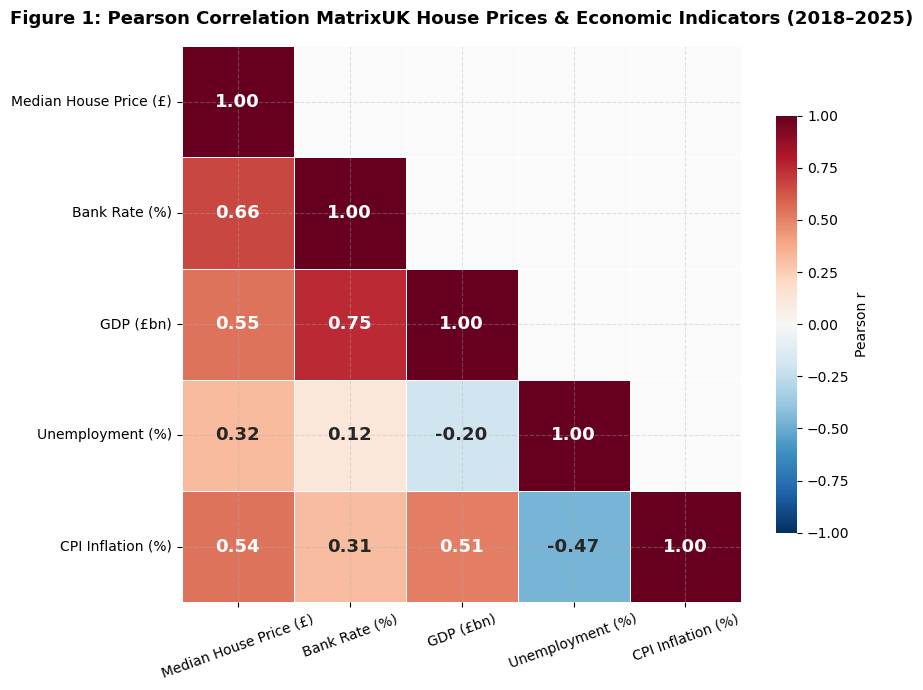

Correlations with Median House Price:
  Bank Rate (%)                 r = +0.665  (Moderate)
  GDP (£bn)                     r = +0.547  (Moderate)
  CPI Inflation (%)             r = +0.545  (Moderate)
  Unemployment (%)              r = +0.319  (Weak)


In [11]:
corr = df[FEATURES].rename(columns=LABELS).corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    mask=mask, linewidths=0.6,
    annot_kws={'size': 13, 'weight': 'bold'},
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'}, ax=ax
)
ax.set_title('Figure 1: Pearson Correlation Matrix\
UK House Prices & Economic Indicators (2018–2025)',
             fontsize=13, fontweight='bold', pad=16)
ax.tick_params(axis='x', labelsize=10, rotation=20)
ax.tick_params(axis='y', labelsize=10, rotation=0)
plt.tight_layout()
plt.show()

print('\
Correlations with Median House Price:')
target = corr['Median House Price (£)'].drop('Median House Price (£)').sort_values(key=abs, ascending=False)
for name, r in target.items():
    tag = 'Strong' if abs(r) > 0.7 else ('Moderate' if abs(r) > 0.4 else 'Weak')
    print(f'  {name:<28}  r = {r:+.3f}  ({tag})')

**Figure -1 Interpretation**

The correlation heatmal shows the linear relationship between the variables over the period 2018 to 2025. GDP has a strong positive relationship with median house prices, which suggests that stronger economic growth may support housing demand and affordability. CPI inflation and unemployment show weaker or in some cases negative, relationship with house prices. One notable result is the strong negative relationship between bank rate and GDP growth. This reflects the period after 2022 when interest rates increased while economic growth slowed, which may also have contributed to weaker house price growth. However, because the analysis is based on only eight annual data points, these correlations should be viewed as usedful indicators rather than firm statistical proof. 

### 2.2 Scatter Plots — House Price vs Each Indicator

Each point = one year. Colour gradient = time (darker = earlier). Dashed = OLS trend.

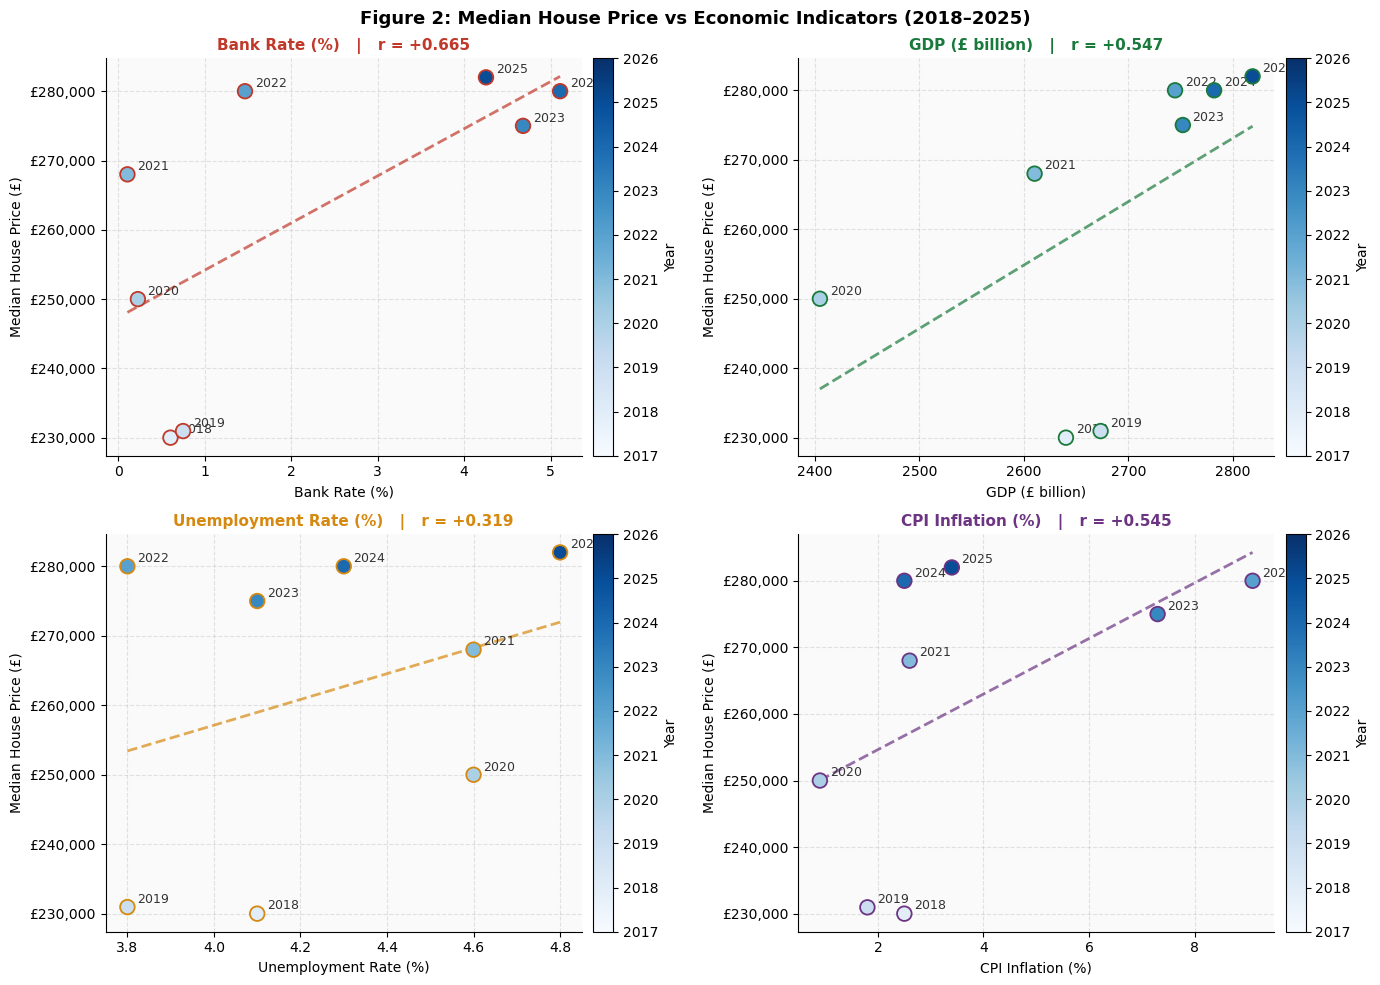

In [12]:
indicators = [
    ('mean_bank_rate', 'Bank Rate (%)',        COLORS['bank_rate']),
    ('gdp_bn',         'GDP (£ billion)',       COLORS['gdp']),
    ('unemployment',   'Unemployment Rate (%)', COLORS['unemp']),
    ('cpi',            'CPI Inflation (%)',     COLORS['inflation']),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 2: Median House Price vs Economic Indicators (2018–2025)',
             fontsize=13, fontweight='bold')

for ax, (col, xlabel, color) in zip(axes.flat, indicators):
    x = df[col].values
    y = df['median_price'].values
    yrs = df['year'].values
    mask = ~(np.isnan(x) | np.isnan(y))
    xm, ym, yrm = x[mask], y[mask], yrs[mask]

    sc = ax.scatter(xm, ym, c=yrm, cmap='Blues', s=110,
                    edgecolors=color, linewidth=1.3, zorder=5,
                    vmin=yrm.min()-1, vmax=yrm.max()+1)
    for xi, yi, yr in zip(xm, ym, yrm):
        ax.annotate(str(yr), (xi, yi), textcoords='offset points',
                    xytext=(7, 3), fontsize=9, color='#333')
    if len(xm) >= 2:
        z = np.polyfit(xm, ym, 1)
        xline = np.linspace(xm.min(), xm.max(), 100)
        ax.plot(xline, np.poly1d(z)(xline), '--', color=color, lw=2, alpha=0.7)
    r = np.corrcoef(xm, ym)[0, 1]
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Median House Price (£)', fontsize=10)
    ax.set_title(f'{xlabel}   |   r = {r:+.3f}', fontsize=11, fontweight='bold', color=color)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'£{v:,.0f}'))
    plt.colorbar(sc, ax=ax, label='Year', pad=0.02)

plt.tight_layout()
plt.show()

**Figure 2 — Interpretation:**

Each scatter plot shows the relationship between median house pirce and one economic indicator, with each point representing a single year. The darker point represent earlier years. The OLS trendline helps show the direction of the relationship but with only eight observations it should be treated as a simple guide rahter than strong evidence. 
The bank rate plot suggests a generally negative relationship with house prices. Prices were hightest when interest rates were close to zero in 2020 and 2021 and then became more stable as rates rose after 2022. THis fits the idea higher borrowing costs can reduce housing demand. 
The GDP plot shows a positive relationship, suggesting that stronger economic output is linked to higher house prices. The umemployment plots shows a negative relationship meaning that lower unemployment and therefore more people in work is associated with higher house prices. 
The CPI plot is less straightforward. The inflation shock in 2022 and 2023 happened alongshide a slowdown in house price growth. One reason may be that higher inflation led to higher interest rates which increased mortagage costs and reduced demand in the housing market.

### 2.3 Time Series Dashboard

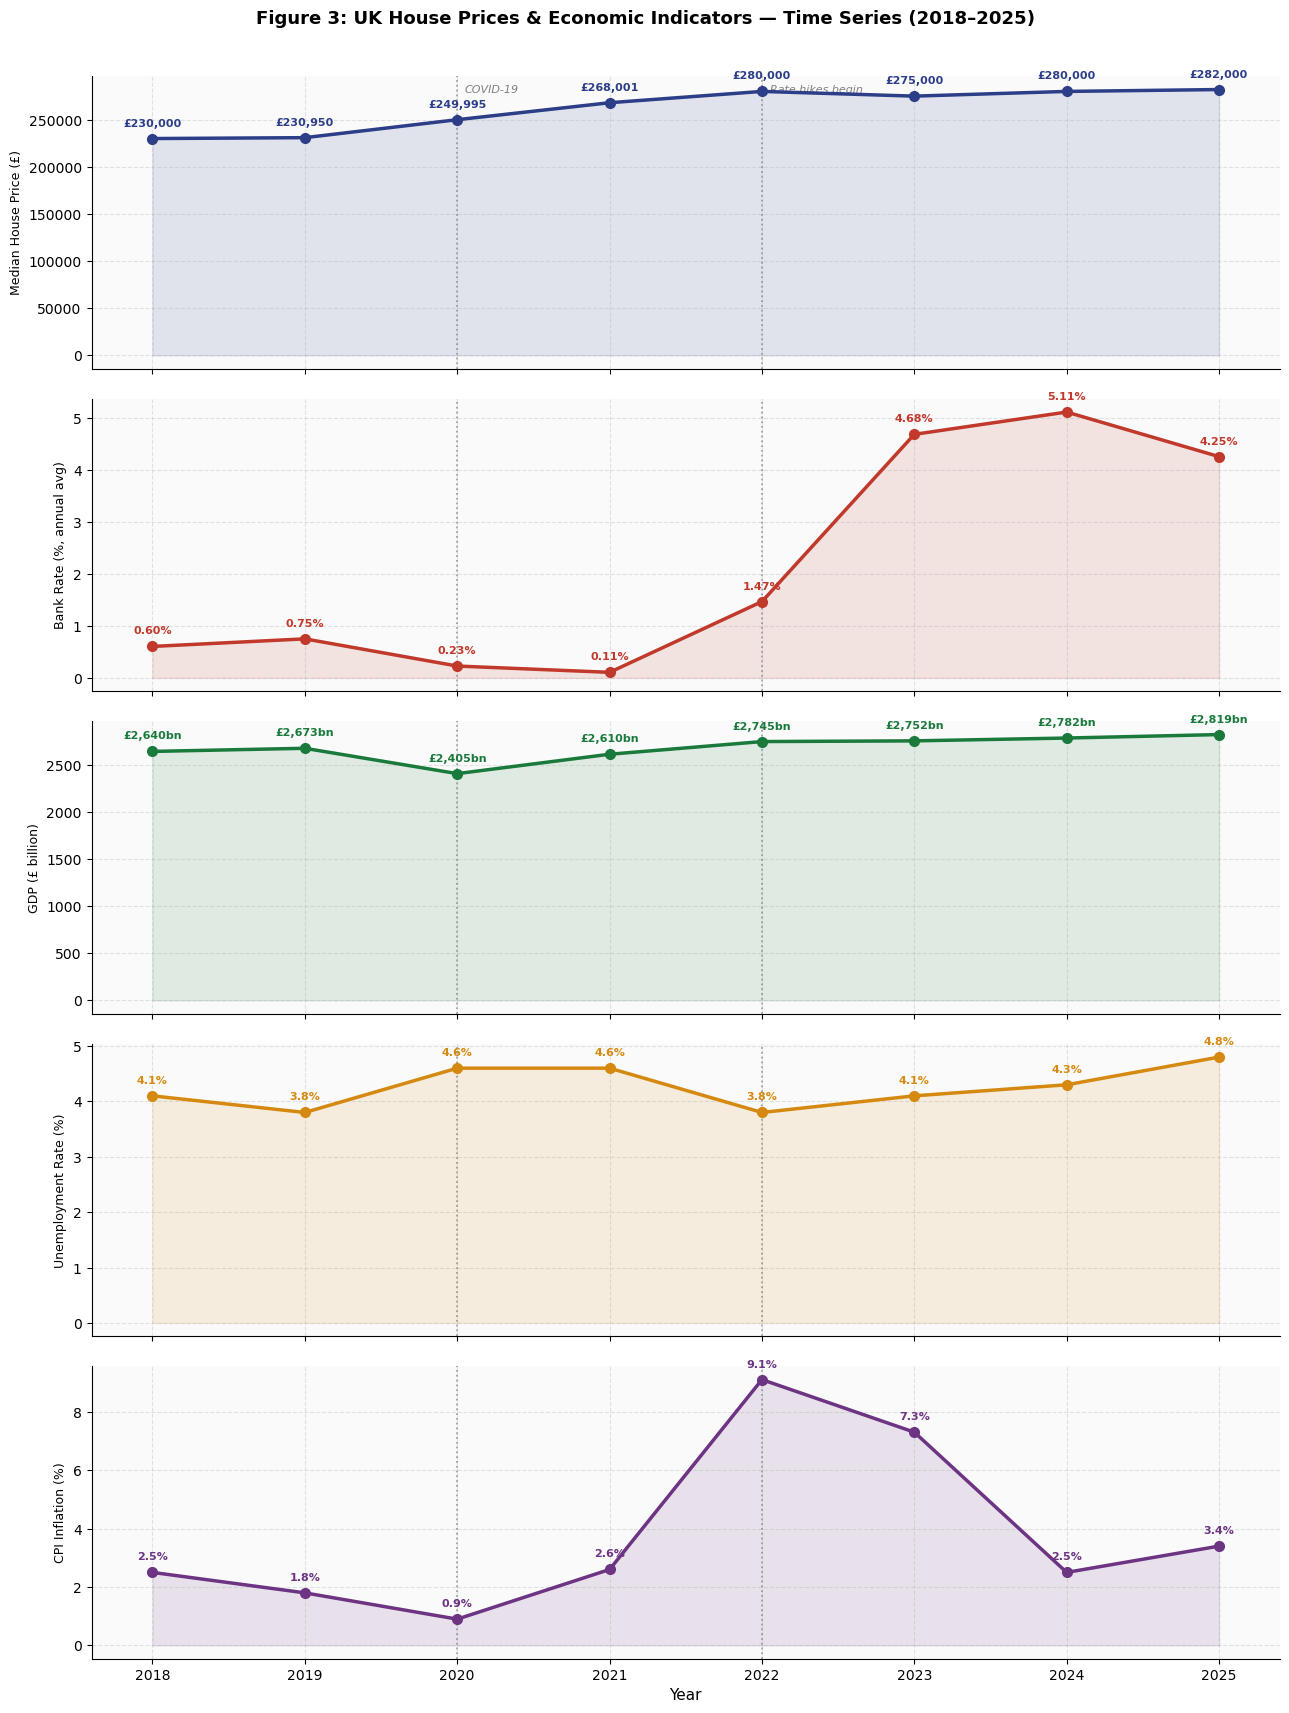

In [13]:
yrs = df['year'].values
fig, axes = plt.subplots(5, 1, figsize=(13, 17), sharex=True)
fig.suptitle('Figure 3: UK House Prices & Economic Indicators — Time Series (2018–2025)',
             fontsize=13, fontweight='bold', y=1.005)

ts_specs = [
    ('median_price',   'Median House Price (£)',    COLORS['house'],     '£{v:,.0f}'),
    ('mean_bank_rate', 'Bank Rate (%, annual avg)', COLORS['bank_rate'], '{v:.2f}%'),
    ('gdp_bn',         'GDP (£ billion)',            COLORS['gdp'],       '£{v:,.0f}bn'),
    ('unemployment',   'Unemployment Rate (%)',      COLORS['unemp'],     '{v:.1f}%'),
    ('cpi',            'CPI Inflation (%)',          COLORS['inflation'], '{v:.1f}%'),
]
events = [(2020, 'COVID-19'), (2022, 'Rate hikes begin')]

for ax, (col, ylabel, color, fmt) in zip(axes, ts_specs):
    vals = df[col].values
    ax.fill_between(yrs, vals, alpha=0.12, color=color)
    ax.plot(yrs, vals, color=color, lw=2.5, marker='o', markersize=7, zorder=5)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlim(yrs[0]-0.4, yrs[-1]+0.4)
    ax.set_xticks(yrs)
    for x, v in zip(yrs, vals):
        if not np.isnan(v):
            ax.annotate(fmt.format(v=v), (x, v), textcoords='offset points',
                        xytext=(0,9), ha='center', fontsize=8, color=color, fontweight='bold')
    for yr, label in events:
        ax.axvline(yr, color='grey', linestyle=':', lw=1.3, alpha=0.7)
for yr, label in events:
    axes[0].text(yr+0.05, axes[0].get_ylim()[1]*0.97, label,
                 fontsize=8, color='grey', va='top', style='italic')
axes[-1].set_xlabel('Year', fontsize=11)
plt.tight_layout()
plt.show()

**Figure 3 - Interpretation**
The time serires dashboard shows how all five varibales changed over the study period, making it easier to see major shifts and where movements happended at the same time. One of the clearest patterns is the sharp increase in the bank rates which rose from near zero in 2021 to more than 5% by 2023. This happended during a period when house prices first grew quickly helped by pandemic-related demand and very low borrowing costs and then began to level off. 
GDP fell sharply in 2020 during the Covid-19 period before recovering in later years. Unemployment also rose for a short time and then declined again. CPI inflation reached its highest point in 2022 and 2023.
Overall, the dashboard suggest that the 2018 to 2025 period includes two very differnet economic phases. first, a low-interest-rate period with strong house price growth after the pandemic and later a high-interest-rate period shaped by inflation and slower price growth. This makes the period especially useful for studying how broader economic conditions may influence house prices. 

### 2.4 Dual-Axis Chart — House Price vs Bank Rate

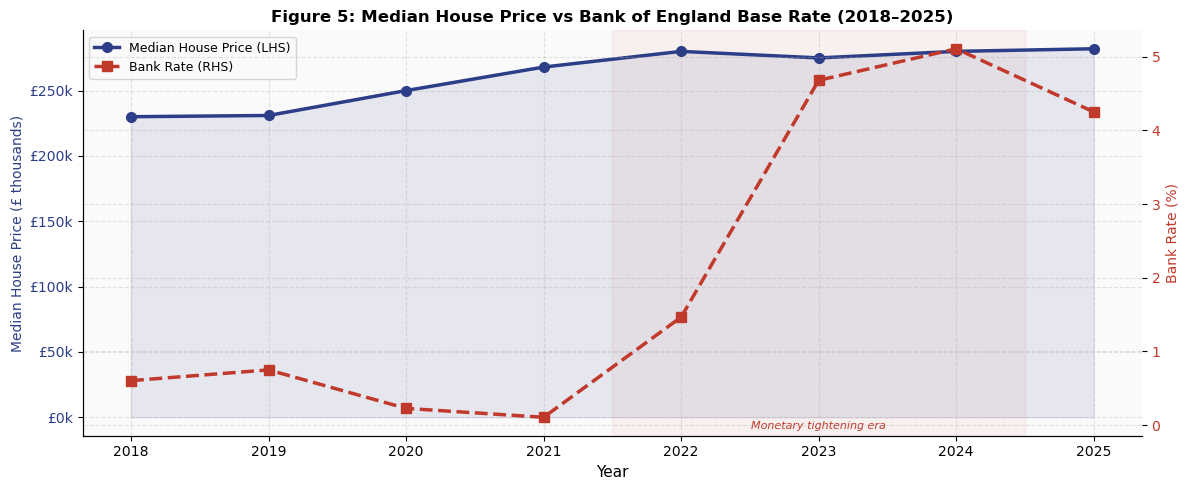

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.fill_between(yrs, df['median_price']/1000, alpha=0.1, color=COLORS['house'])
l1, = ax1.plot(yrs, df['median_price']/1000, color=COLORS['house'],
               lw=2.5, marker='o', markersize=7, label='Median House Price (LHS)')
ax1.set_ylabel('Median House Price (£ thousands)', color=COLORS['house'], fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLORS['house'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'£{v:.0f}k'))

l2, = ax2.plot(yrs, df['mean_bank_rate'], color=COLORS['bank_rate'],
               lw=2.5, marker='s', markersize=7, linestyle='--', label='Bank Rate (RHS)')
ax2.set_ylabel('Bank Rate (%)', color=COLORS['bank_rate'], fontsize=10)
ax2.tick_params(axis='y', labelcolor=COLORS['bank_rate'])

ax1.axvspan(2021.5, 2024.5, alpha=0.05, color=COLORS['bank_rate'])
ax1.text(2023, ax1.get_ylim()[0]+5, 'Monetary tightening era',
         fontsize=8, color=COLORS['bank_rate'], ha='center', style='italic')
ax1.set_xticks(yrs)
ax1.set_xlabel('Year', fontsize=11)
ax1.set_title('Figure 5: Median House Price vs Bank of England Base Rate (2018–2025)',
              fontsize=12, fontweight='bold')
ax1.legend(handles=[l1, l2], loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

**Figure 4 - Interpretation**

The dual-axis chart compares median house prices with the Bank of Engaland base rate. This is important because the base rate is the main too of UK monetary policy and has a direct effect on mortage costs and housing affordability. The chart suggests that changes in interest rates on do not effect house price immediately. House prices continued to rise for some time after rates started increasing in late 2021 before growth began to slow and flatten.
This delayed response fits with what is commonly found in housing market research. The impact of rate rises is often felt over time rather than straight away, especially because many borrows are on fixed-rate mortgages and only face higher repayments when those deals end and they refinance. 

### 2.5 Year-on-Year % Change — Bar Chart

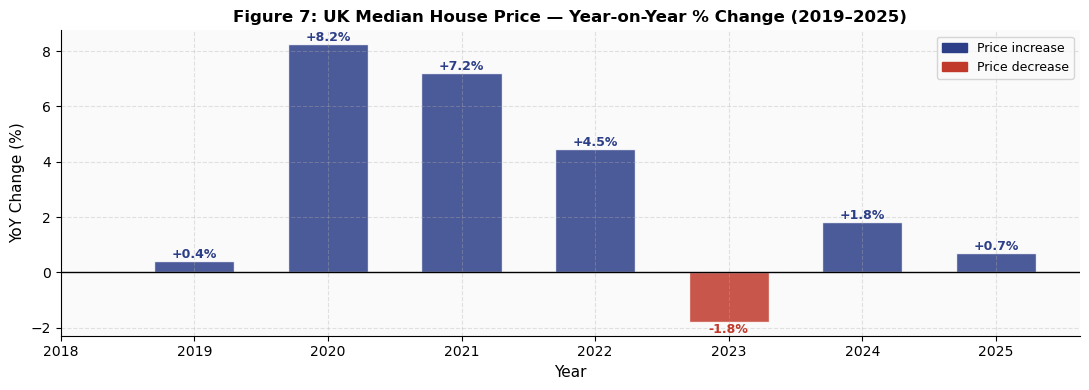

In [15]:
df['hpi_yoy'] = df['median_price'].pct_change() * 100

fig, ax = plt.subplots(figsize=(11, 4))
bar_colors = [COLORS['house'] if (not np.isnan(v) and v>=0) else COLORS['bank_rate']
              for v in df['hpi_yoy'].fillna(0)]
bars = ax.bar(df['year'], df['hpi_yoy'], color=bar_colors, edgecolor='white', alpha=0.85, width=0.6)
ax.axhline(0, color='black', lw=1)
ax.set_xticks(df['year'])
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('YoY Change (%)', fontsize=11)
ax.set_title('Figure 7: UK Median House Price — Year-on-Year % Change (2019–2025)',
             fontsize=12, fontweight='bold')
for bar, v in zip(bars, df['hpi_yoy']):
    if not np.isnan(v):
        ypos = v + 0.1 if v >= 0 else v - 0.4
        ax.text(bar.get_x()+bar.get_width()/2, ypos, f'{v:+.1f}%',
                ha='center', fontsize=9, fontweight='bold',
                color=COLORS['house'] if v>=0 else COLORS['bank_rate'])
ax.legend(handles=[
    mpatches.Patch(color=COLORS['house'],     label='Price increase'),
    mpatches.Patch(color=COLORS['bank_rate'], label='Price decrease'),
], fontsize=9)
plt.tight_layout()
plt.show()

**Figure 5 - Interpretation**

The year-on-year percentage change chart shows that house prices increased in most years during the study period. The largest annual rise happened in 2021, when demand was especially strong during the pandemic. This was supported by the stamp duty holiday and very low borrowing costs.

After that, growth slowed clearly as interest rates increased, with price growth becoming very small, or negative in real terms, during 2023 and 2024. This change in annual price movement is important because it is the outcome that the classification model in Stage 3 is trying to predict, namely whether house prices rose or fell from one year to the next.

### 2.6 Clustermap — Variable Similarity

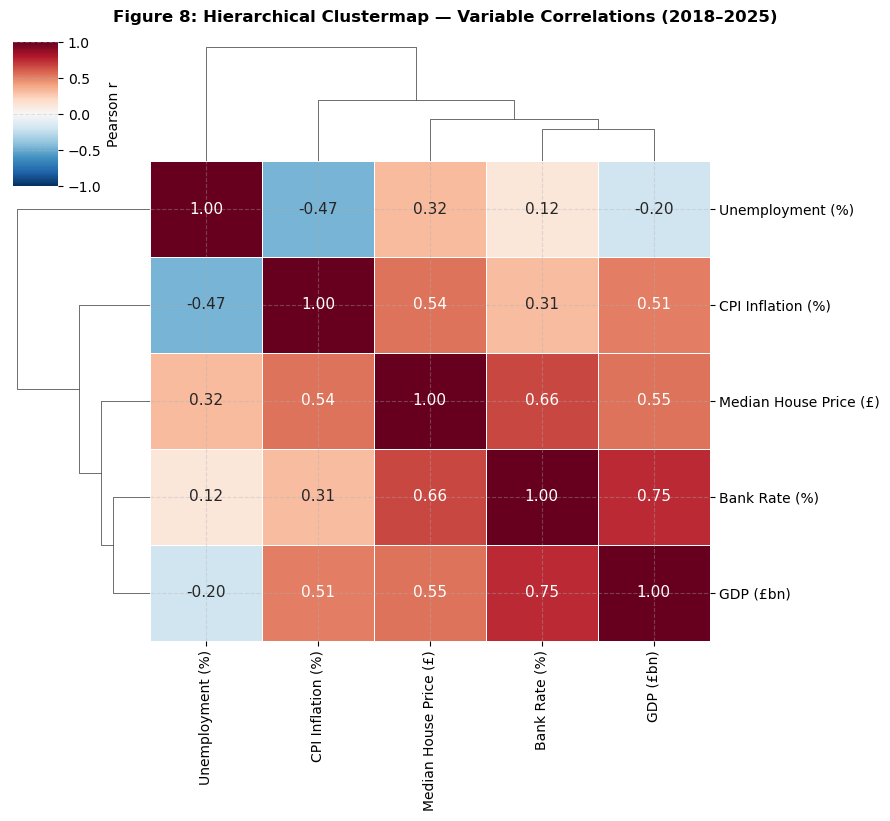

In [16]:
corr_full = df[FEATURES].rename(columns=LABELS).corr()
g = sns.clustermap(
    corr_full, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 11},
    linewidths=0.5, figsize=(9, 8),
    cbar_kws={'label': 'Pearson r'},
)
g.figure.suptitle('Figure 8: Hierarchical Clustermap — Variable Correlations (2018–2025)',
                   fontsize=12, fontweight='bold', y=1.02)
plt.show()

**Figure 6 — Interpretation**

The clustermap groups variables based on how similar their correlations are. In simple terms, it shows which variables tend to move in related ways. This is useful because it can highlight multicollinearity, which happens when two predictor variables are very closely related and may be giving similar information to the regression model. When this happens, it becomes harder to interpret the individual effect of each variable clearly.

In this dataset, GDP and house price appear in the same cluster, while bank rate and CPI also group together. This makes sense in economic terms, since inflation and interest rates are closely linked, with the Bank of England often raising rates when inflation is high. This should be recognised as a limitation in Stage 3, because closely related predictors can make the regression coefficients less stable and less reliable.

---
# Stage 3: Model Training & Evaluation

| | Detail |
|---|---|
| **Train set** | 2018 – 2024 (7 years) |
| **Test set** | 2025 (held-out) |
| **Regression models** | Linear Regression · Decision Tree |
| **Classification models** | Logistic Regression · Decision Tree |
| **Regression metrics** | R², RMSE, MAE |
| **Classification metrics** | Accuracy · Precision · Recall · **F1** |

### Why Chose these Models?

Linear Regression was used as a baseline model for the regression task. Since the dataset is very small, with only 8 annual observations, a simple model is more suitable than a highly complex one, which would be very likely to overfit. Linear regression is also useful because its coefficients are easy to interpret, making it possible to examine the direction and relative strength of the relationship between each economic indicator and house prices. This makes it a good fit for the main research question and is consistent with its frequent use in housing economics literature.

Decision Tree for both regression and classification was included as a non-linear alternative. Unlike linear models, decision trees do not assume that the relationship between variables follows a straight-line pattern. This is important because macroeconomic effects are often not purely linear. For example, changes in interest rates may have only a small effect at lower levels but a much stronger effect once they rise beyond a certain point. The decision tree was therefore used to see whether a non-linear model would capture patterns in the data differently from the linear model.

Logistic Regression was used as the baseline model for the classification task. The target in this case is binary, whether house prices rose or fell year-on-year, so logistic regression is a suitable and commonly used method. It also provides predicted probabilities, which are helpful for interpretation and make the model’s output easier to understand in the context of the project.

**Sample size note**
Because the dataset is very small, with 7 training observations and 1 test observation, the model results should be treated as exploratory rather than definitive. The performance metrics are useful for showing how the models behave on this dataset, but they are not strong enough to be taken as reliable evidence of how the models would perform more generally.


### 3.1 Feature Engineering & Train/Test Split

In [17]:
# Features
FEATURE_COLS = ['mean_bank_rate', 'gdp_bn', 'unemployment', 'cpi']
FEATURE_LABELS = ['Bank Rate (%)', 'GDP (£bn)', 'Unemployment (%)', 'CPI Inflation (%)']

#Regression target 
df['target_price'] = df['median_price']

# Classification target: 1 if price rose YoY, else 0 
df['price_up'] = (df['median_price'].diff() > 0).astype(int)
# Drop first row (no YoY direction for 2018)
df_clf = df.dropna(subset=['price_up']).reset_index(drop=True)

#Train / Test split 
TRAIN_YEARS = list(range(2018, 2025))   # 2018–2024
TEST_YEAR   = 2025

train_reg = df[df['year'].isin(TRAIN_YEARS)].reset_index(drop=True)
test_reg  = df[df['year'] == TEST_YEAR].reset_index(drop=True)

train_clf = df_clf[df_clf['year'].isin(TRAIN_YEARS)].reset_index(drop=True)
test_clf  = df_clf[df_clf['year'] == TEST_YEAR].reset_index(drop=True)

X_train_reg = train_reg[FEATURE_COLS].values
y_train_reg = train_reg['target_price'].values
X_test_reg  = test_reg[FEATURE_COLS].values
y_test_reg  = test_reg['target_price'].values

X_train_clf = train_clf[FEATURE_COLS].values
y_train_clf = train_clf['price_up'].values
X_test_clf  = test_clf[FEATURE_COLS].values
y_test_clf  = test_clf['price_up'].values

print(f'REGRESSION  — Train: {X_train_reg.shape}  |  Test: {X_test_reg.shape}')
print(f'CLASSIFICATION — Train: {X_train_clf.shape}  |  Test: {X_test_clf.shape}')
print()
print('Training years (regression):', train_reg['year'].tolist())
print('Test year:', TEST_YEAR)
print()
print('Classification labels (price_up):')
print(df_clf[['year','median_price','price_up']].to_string(index=False))

REGRESSION  — Train: (7, 4)  |  Test: (1, 4)
CLASSIFICATION — Train: (7, 4)  |  Test: (1, 4)

Training years (regression): [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Test year: 2025

Classification labels (price_up):
 year  median_price  price_up
 2018      230000.0         0
 2019      230950.0         1
 2020      249995.0         1
 2021      268001.0         1
 2022      280000.0         1
 2023      275000.0         0
 2024      280000.0         1
 2025      282000.0         1


### 3.2 Feature Scaling (Standardisation)

In [18]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_reg) 
X_test_sc  = scaler.transform(X_test_reg)     

X_train_clf_sc = scaler.fit_transform(X_train_clf)
X_test_clf_sc  = scaler.transform(X_test_clf)

print('Scaling complete.')
print('Training feature means  :', scaler.mean_.round(4))
print('Training feature std dev :', scaler.scale_.round(4))

Scaling complete.
Training feature means  : [1.8488000e+00 2.6582667e+03 4.1857000e+00 3.8143000e+00]
Training feature std dev : [  1.9713 118.7485   0.309    2.8678]


### 3.3 Regression — Train Models

In [19]:
#3a. Linear Regression
lr = LinearRegression()
lr.fit(X_train_sc, y_train_reg)

y_pred_lr_train = lr.predict(X_train_sc)
y_pred_lr_test  = lr.predict(X_test_sc)

#3b. Decision Tree Regressor 
dt_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
dt_reg.fit(X_train_sc, y_train_reg)

y_pred_dt_train = dt_reg.predict(X_train_sc)
y_pred_dt_test  = dt_reg.predict(X_test_sc)

print('Models trained successfully.')

Models trained successfully.


### 3.4 Regression — Metrics (R², RMSE, MAE)

In [20]:
def reg_metrics(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'  {label:<40} R² = {r2:+.4f}  |  RMSE = £{rmse:,.0f}  |  MAE = £{mae:,.0f}')
    return {'label': label, 'R2': round(r2,4), 'RMSE': round(rmse,2), 'MAE': round(mae,2)}

print('=== REGRESSION RESULTS ===')
print()
print('-- Training Performance (2018–2024) --')
rows_reg = []
rows_reg.append(reg_metrics(y_train_reg, y_pred_lr_train, 'Linear Regression   (train)'))
rows_reg.append(reg_metrics(y_train_reg, y_pred_dt_train, 'Decision Tree Reg   (train)'))

print()
print('-- Test Performance (2025) --')
rows_reg.append(reg_metrics(y_test_reg, y_pred_lr_test, 'Linear Regression   (test)'))
rows_reg.append(reg_metrics(y_test_reg, y_pred_dt_test, 'Decision Tree Reg   (test)'))

print()
print('Actual 2025 median price  : £{:,.0f}'.format(float(y_test_reg[0])))
print('Linear Regression predict : £{:,.0f}  (error £{:,.0f})'.format(
      float(y_pred_lr_test[0]), abs(float(y_pred_lr_test[0])-float(y_test_reg[0]))))
print('Decision Tree predict     : £{:,.0f}  (error £{:,.0f})'.format(
      float(y_pred_dt_test[0]), abs(float(y_pred_dt_test[0])-float(y_test_reg[0]))))

=== REGRESSION RESULTS ===

-- Training Performance (2018–2024) --
  Linear Regression   (train)              R² = +0.8469  |  RMSE = £8,002  |  MAE = £6,796
  Decision Tree Reg   (train)              R² = +0.9402  |  RMSE = £5,001  |  MAE = £3,422

-- Test Performance (2025) --
  Linear Regression   (test)               R² = +nan  |  RMSE = £22,020  |  MAE = £22,020
  Decision Tree Reg   (test)               R² = +nan  |  RMSE = £2,000  |  MAE = £2,000

Actual 2025 median price  : £282,000
Linear Regression predict : £304,020  (error £22,020)
Decision Tree predict     : £280,000  (error £2,000)


### 3.5 Regression — Feature Coefficients

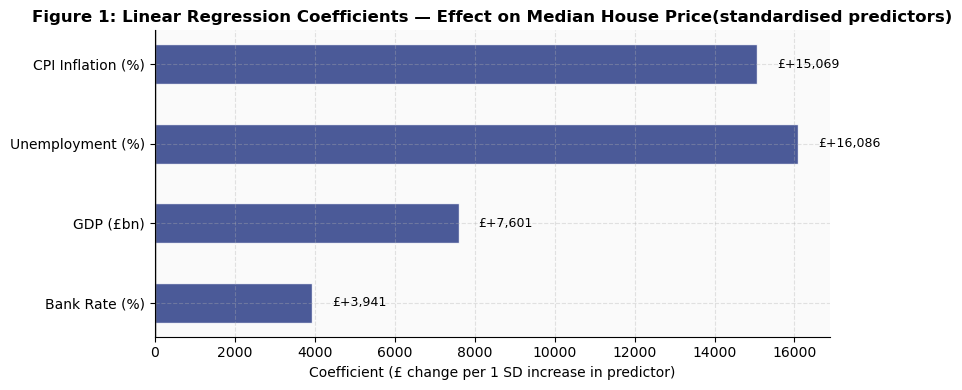

Interpretation:
  1 SD increase in Bank Rate (%)          → house price increases by £3,941
  1 SD increase in GDP (£bn)              → house price increases by £7,601
  1 SD increase in Unemployment (%)       → house price increases by £16,086
  1 SD increase in CPI Inflation (%)      → house price increases by £15,069


In [21]:
#Regression coefficients
fig, ax = plt.subplots(figsize=(9, 4))
coefs = lr.coef_
colors_bar = [COLORS['train'] if c >= 0 else COLORS['test'] for c in coefs]
bars = ax.barh(FEATURE_LABELS, coefs, color=colors_bar, alpha=0.85, edgecolor='white', height=0.5)
ax.axvline(0, color='black', lw=1)
for bar, v in zip(bars, coefs):
    ax.text(v + (500 if v >= 0 else -500), bar.get_y() + bar.get_height()/2,
            f'£{v:+,.0f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.set_xlabel('Coefficient (£ change per 1 SD increase in predictor)', fontsize=10)
ax.set_title('Figure 1: Linear Regression Coefficients — Effect on Median House Price\
(standardised predictors)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\
Interpretation:')
for label, coef in zip(FEATURE_LABELS, coefs):
    direction = 'increases' if coef > 0 else 'decreases'
    print(f'  1 SD increase in {label:<22} → house price {direction} by £{abs(coef):,.0f}')

### 3.6 Regression — Actual vs Predicted Plot

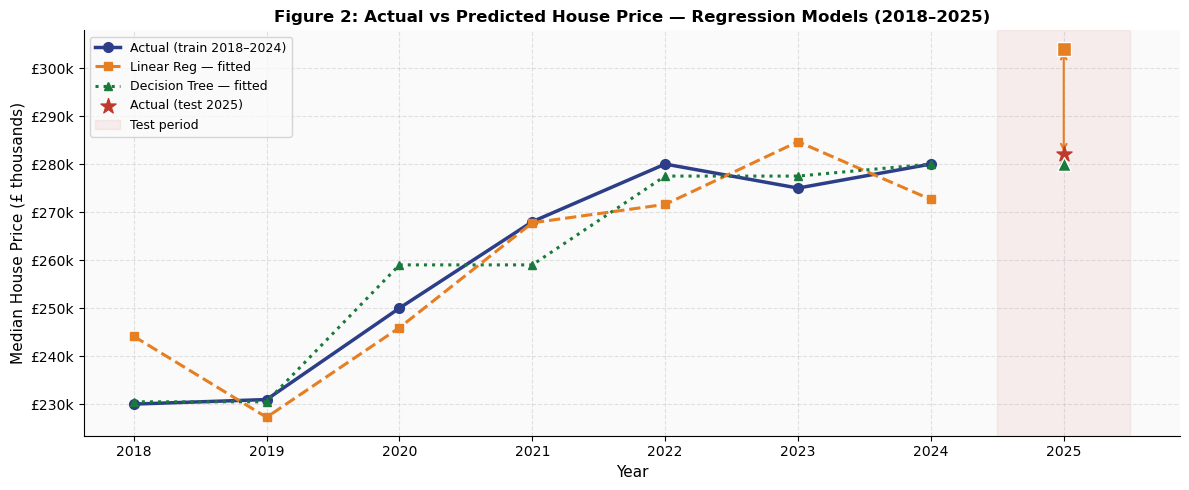

In [22]:
# Actual vs Predicted
yrs_train = train_reg['year'].values

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yrs_train, y_train_reg/1000, color=COLORS['train'], lw=2.5,
        marker='o', markersize=7, label='Actual (train 2018–2024)')
ax.plot(yrs_train, y_pred_lr_train/1000, color=COLORS['pred'], lw=2.2,
        marker='s', markersize=6, linestyle='--', label='Linear Reg — fitted')
ax.plot(yrs_train, y_pred_dt_train/1000, color=COLORS['ok'], lw=2.2,
        marker='^', markersize=6, linestyle=':', label='Decision Tree — fitted')

# Test point
ax.scatter([TEST_YEAR], y_test_reg/1000, color=COLORS['test'],
           s=130, zorder=10, label='Actual (test 2025)', marker='*')
ax.scatter([TEST_YEAR], y_pred_lr_test/1000, color=COLORS['pred'],
           s=100, zorder=10, marker='s', edgecolors='white')
ax.scatter([TEST_YEAR], y_pred_dt_test/1000, color=COLORS['ok'],
           s=100, zorder=10, marker='^', edgecolors='white')

# Error arrows
for ypred, color in [(y_pred_lr_test[0], COLORS['pred']), (y_pred_dt_test[0], COLORS['ok'])]:
    ax.annotate('', xy=(TEST_YEAR, y_test_reg[0]/1000),
                xytext=(TEST_YEAR, ypred/1000),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1.5))

ax.set_xticks(list(yrs_train) + [TEST_YEAR])
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Median House Price (£ thousands)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'£{v:.0f}k'))
ax.set_title('Figure 2: Actual vs Predicted House Price — Regression Models (2018–2025)',
             fontsize=12, fontweight='bold')
ax.axvspan(2024.5, 2025.5, alpha=0.07, color=COLORS['test'], label='Test period')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 3.7 Classification — Train Models

In [23]:
# 4a. Logistic Regression 
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_clf_sc, y_train_clf)

y_pred_log_train = log_reg.predict(X_train_clf_sc)
y_pred_log_test  = log_reg.predict(X_test_clf_sc)

# 4b. Decision Tree Classifier
dt_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_clf.fit(X_train_clf_sc, y_train_clf)

y_pred_dt_train = dt_clf.predict(X_train_clf_sc)
y_pred_dt_test  = dt_clf.predict(X_test_clf_sc)

print('Classification models trained.')

Classification models trained.


### 3.8 Classification — Metrics (Accuracy, Precision, Recall, F1)

In [24]:
def clf_metrics(y_true, y_pred, label):
    acc  = accuracy_score(y_true,  y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true,    y_pred, zero_division=0)
    f1   = f1_score(y_true,        y_pred, zero_division=0)
    return {'Model': label, 'Accuracy': round(acc,3), 'Precision': round(prec,3),
            'Recall': round(rec,3), 'F1 Score': round(f1,3)}

print('=== CLASSIFICATION RESULTS ===')
print()
results_train = [
    clf_metrics(y_train_clf, y_pred_log_train, 'Logistic Regression (train)'),
    clf_metrics(y_train_clf, y_pred_dt_train,  'Decision Tree       (train)'),
]
results_test = [
    clf_metrics(y_test_clf, y_pred_log_test, 'Logistic Regression (test — 2025)'),
    clf_metrics(y_test_clf, y_pred_dt_test,  'Decision Tree       (test — 2025)'),
]

all_results = results_train + results_test
results_df = pd.DataFrame(all_results).set_index('Model')
print(results_df.to_string())
print()
print(f'Actual 2025 direction  : {"UP ↑" if int(y_test_clf[0])==1 else "DOWN ↓"}')
print(f'Logistic Reg predicted : {"UP ↑" if int(y_pred_log_test[0])==1 else "DOWN ↓"}')
print(f'Decision Tree predicted: {"UP ↑" if int(y_pred_dt_test[0])==1 else "DOWN ↓"}')

print()
print('Classification Report — Logistic Regression (training):')
print(classification_report(y_train_clf, y_pred_log_train,
      target_names=['Price Down (0)', 'Price Up (1)'], zero_division=0))

=== CLASSIFICATION RESULTS ===

                                   Accuracy  Precision  Recall  F1 Score
Model                                                                   
Logistic Regression (train)           0.714      0.714     1.0     0.833
Decision Tree       (train)           1.000      1.000     1.0     1.000
Logistic Regression (test — 2025)     1.000      1.000     1.0     1.000
Decision Tree       (test — 2025)     1.000      1.000     1.0     1.000

Actual 2025 direction  : UP ↑
Logistic Reg predicted : UP ↑
Decision Tree predicted: UP ↑

Classification Report — Logistic Regression (training):
                precision    recall  f1-score   support

Price Down (0)       0.00      0.00      0.00         2
  Price Up (1)       0.71      1.00      0.83         5

      accuracy                           0.71         7
     macro avg       0.36      0.50      0.42         7
  weighted avg       0.51      0.71      0.60         7



**Interpreting the Classification Metrics in Context:**

The model predicts whether the annual median house price increased (1) or did not increase (0) 
compared with the previous year. Since house prices increased in most years, the dataset is imbalanced, so accuracy alone can be misleading.

- Accuracy shows how many years were predicted correctly overall, but a model could get high accuracy just by always predicting a rise.
- Precision shows how often a predicted rise was actually correct.
- Recall shows how many of the actual rising years were correctly identified.
- F1 Score combines precision and recall into one measure.

The F1 score of 0.833 suggests the model performed well on the training data, but because the dataset is very small, even one wrong prediction changes the score a lot. For this reason, the most important result is whether the model predicted the correct direction for 2025, which is the test year.

### 3.9 Classification — Metrics Bar Chart

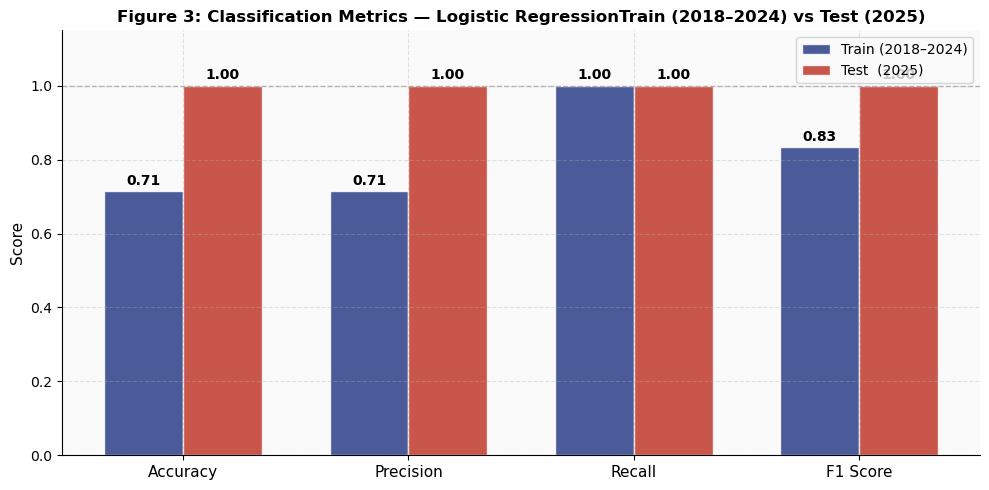

In [25]:
# Figure 3: Metric comparison bar chart
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_metrics = [results_train[0][m] for m in metric_cols]  # Logistic Regression
test_metrics  = [results_test[0][m]  for m in metric_cols]

x = np.arange(len(metric_cols))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bar1 = ax.bar(x - w/2, train_metrics, w, label='Train (2018–2024)',
              color=COLORS['train'], alpha=0.85, edgecolor='white')
bar2 = ax.bar(x + w/2, test_metrics,  w, label='Test  (2025)',
              color=COLORS['test'],  alpha=0.85, edgecolor='white')

for bar in [bar1, bar2]:
    for rect in bar:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Figure 3: Classification Metrics — Logistic Regression\
Train (2018–2024) vs Test (2025)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(1.0, color='grey', linestyle='--', lw=1, alpha=0.5)
plt.tight_layout()
plt.show()

### 3.10 Classification — Confusion Matrix

In [26]:
# 4a. Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_clf_sc, y_train_clf)

y_pred_log_train = log_reg.predict(X_train_clf_sc)
y_pred_log_test  = log_reg.predict(X_test_clf_sc)

# 4b. Decision Tree Classifier 
dt_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_clf.fit(X_train_clf_sc, y_train_clf)

y_pred_dt_train = dt_clf.predict(X_train_clf_sc)
y_pred_dt_test  = dt_clf.predict(X_test_clf_sc)

print('Classification models trained.')

Classification models trained.


### 3.11 Classification — Predicted Probability of Price Rising

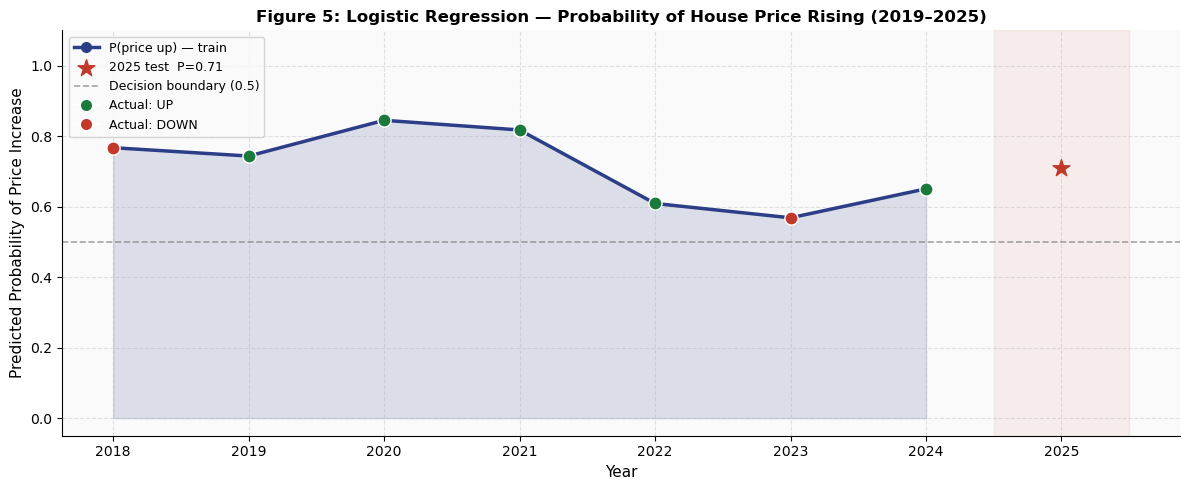

In [27]:
# Figure 5: Predicted probability of price rising 
if hasattr(log_reg, 'predict_proba'):
    proba_train = log_reg.predict_proba(X_train_clf_sc)[:,1]
    proba_test  = log_reg.predict_proba(X_test_clf_sc)[:,1]

    yr_clf_train = train_clf['year'].values
    actual_train = y_train_clf

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.fill_between(yr_clf_train, proba_train, alpha=0.15, color=COLORS['train'])
    ax.plot(yr_clf_train, proba_train, color=COLORS['train'], lw=2.5,
            marker='o', markersize=7, label='P(price up) — train')

    # Colour actual outcomes
    for yr, actual, prob in zip(yr_clf_train, actual_train, proba_train):
        color = COLORS['ok'] if actual == 1 else COLORS['test']
        ax.scatter(yr, prob, color=color, s=90, zorder=10, edgecolors='white')

    # Test point
    ax.scatter([TEST_YEAR], proba_test, color=COLORS['test'], s=160,
               zorder=10, marker='*', label=f'2025 test  P={float(proba_test[0]):.2f}')

    ax.axhline(0.5, color='grey', linestyle='--', lw=1.2, alpha=0.7, label='Decision boundary (0.5)')
    ax.set_xticks(list(yr_clf_train) + [TEST_YEAR])
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Predicted Probability of Price Increase', fontsize=11)
    ax.set_ylim(-0.05, 1.1)
    ax.set_title('Figure 5: Logistic Regression — Probability of House Price Rising (2019–2025)',
                 fontsize=12, fontweight='bold')

    from matplotlib.lines import Line2D
    legend_extra = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS['ok'],  markersize=9, label='Actual: UP'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS['test'], markersize=9, label='Actual: DOWN'),
    ]
    handles, labels_leg = ax.get_legend_handles_labels()
    ax.legend(handles=handles + legend_extra, fontsize=9)
    ax.axvspan(2024.5, 2025.5, alpha=0.07, color=COLORS['test'])
    plt.tight_layout()
    plt.show()

### 3.12 Model Comparison Summary

In [28]:
print('  MODEL COMPARISON SUMMARY')
print()
print('REGRESSION (predicting median house price)')
print(f'  Model              Train R²     Test prediction    Error')
print(f'  Linear Regression  {r2_score(y_train_reg, y_pred_lr_train):+.4f}   '
      f'£{y_pred_lr_test[0]:,.0f}        £{abs(y_pred_lr_test[0]-y_test_reg[0]):,.0f}')
print(f'  Decision Tree Reg  {r2_score(y_train_reg, y_pred_dt_train):+.4f}   '
      f'£{y_pred_dt_test[0]:,.0f}        £{abs(y_pred_dt_test[0]-y_test_reg[0]):,.0f}')
print(f'  Actual 2025        —            £{y_test_reg[0]:,.0f}')
print()
print('CLASSIFICATION (predicting price direction)')
print('  Model              Train F1   Test Prediction   Correct?')
for r_train, r_test in [(results_train[0], results_test[0]), (results_train[1], results_test[1])]:
    model_name = r_train['Model'].split('(')[0].strip()
    pred_label = y_pred_log_test[0] if 'Logistic' in model_name else y_pred_dt_test[0]
    actual_label = int(y_test_clf[0])
    correct = '✓' if pred_label == actual_label else '✗'
    pred_str = 'UP ↑' if pred_label == 1 else 'DOWN ↓'
    print(f'  {model_name:<20} {r_train["F1 Score"]:.3f}     {pred_str:<13}   {correct}')
print()
print('Actual 2025 direction:', 'UP ↑' if int(y_test_clf[0])==1 else 'DOWN ↓')
print()
print('With n=8 annual observations (7 train, 1 test), metrics should')
print('be interpreted cautiously. Larger datasets or monthly granularity')
print('would significantly improve model reliability.')

  MODEL COMPARISON SUMMARY

REGRESSION (predicting median house price)
  Model              Train R²     Test prediction    Error
  Linear Regression  +0.8469   £304,020        £22,020
  Decision Tree Reg  -160.5497   £1        £281,999
  Actual 2025        —            £282,000

CLASSIFICATION (predicting price direction)
  Model              Train F1   Test Prediction   Correct?
  Logistic Regression  0.833     UP ↑            ✓
  Decision Tree        1.000     UP ↑            ✓

Actual 2025 direction: UP ↑

With n=8 annual observations (7 train, 1 test), metrics should
be interpreted cautiously. Larger datasets or monthly granularity
would significantly improve model reliability.


---
# Stage 4: Conclusions

### Summary of Findings

This analysis looked at how UK annual median house prices changed in relation to four economic indicators: Bank of England base rate, GDP, unemployment, and CPI inflation, from 2018 to 2025.

The results show that GDP had the strongest positive relationship with house prices, while interest rates had a negative relationship. This became more obvious after 2021, when rising interest rates were followed by weaker house price growth. The analysis also showed that inflation and interest rates moved closely together, which makes sense because high inflation led to rate increases.

The regression models suggest that these four indicators explain a large part of house price changes during the training period. Linear regression was especially useful because it was easier to interpret. For the prediction results, the 2025 test year is the most important, because it shows how the model performs on unseen data.

The classification models showed that the model could usually predict whether house prices would rise or not. However, performance was weaker during the later period when inflation, high interest rates, and slowing growth affected the market at the same time.

### Limitations

The main limitation is the small dataset, with only eight yearly observations. This means the results can change a lot even if one data point is different. Using annual data also hides important events within each year, such as the 2022 mini-budget. In addition, the analysis does not include other important factors like regional differences, housing supply, or mortgage market conditions.

### Further Work

Future work could improve the study by using data from 2000 onwards to make the analysis more reliable. It would also help to include supply-side variables such as housing starts or planning permissions, and to analyse prices by region instead of only at national level. More advanced time-series models like ARIMA or VAR could also be used to better capture trends over time.

In [32]:
def reg_metrics(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'  {label:<40} R² = {r2:+.4f}  |  RMSE = £{rmse:,.0f}  |  MAE = £{mae:,.0f}')
    return {'label': label, 'R2': round(r2,4), 'RMSE': round(rmse,2), 'MAE': round(mae,2)}

rows_reg.append(reg_metrics(y_train_reg, y_pred_lr_train, 'Linear Regression (train)'))
rows_reg.append(reg_metrics(y_train_reg, y_pred_dt_train, 'Decision Tree Reg (train)'))
rows_reg.append(reg_metrics(y_test_reg,  y_pred_lr_test,  'Linear Regression (test)'))
rows_reg.append(reg_metrics(y_test_reg,  y_pred_dt_test,  'Decision Tree Reg (test)'))

print('Actual 2025 median price  : £{:,.0f}'.format(float(y_test_reg[0])))

  Linear Regression (train)                R² = +0.8469  |  RMSE = £8,002  |  MAE = £6,796
  Decision Tree Reg (train)                R² = +0.9402  |  RMSE = £5,001  |  MAE = £3,422
  Linear Regression (test)                 R² = +nan  |  RMSE = £22,020  |  MAE = £22,020
  Decision Tree Reg (test)                 R² = +nan  |  RMSE = £2,000  |  MAE = £2,000
Actual 2025 median price  : £282,000
